<a href="https://colab.research.google.com/github/Srigowri2509/term-project-1/blob/main/Term_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')

# ===== Load Data =====
def read_data(file_path):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
    return df

df_train = read_data('/content/kospi_train.csv')
df_test = read_data('/content/kospi_test.csv')

# ===== Part 1: Create lag features =====
for col in ['Open', 'Low', 'High', 'Close', 'Volume']:
    df_train[f'{col}_lag1'] = df_train[col].shift(1)
    df_test[f'{col}_lag1'] = df_test[col].shift(1)

df_train.dropna(inplace=True)
df_test.dropna(inplace=True)

features = [f'{col}_lag1' for col in ['Open', 'Low', 'High', 'Close', 'Volume']]
target = 'Close'

X_train, y_train = df_train[features], df_train[target]
X_test, y_test = df_test[features], df_test[target]

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': RidgeCV(alphas=np.logspace(-3, 3, 10), cv=5),
    'Lasso': LassoCV(alphas=np.logspace(-3, 3, 10), cv=5),
    'DecisionTree': DecisionTreeRegressor(max_depth=5, random_state=0)
}

results_part1 = []
tscv = TimeSeriesSplit(n_splits=3)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=tscv, scoring='neg_root_mean_squared_error')
    cv_rmse = -np.mean(cv_scores)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_r2 = r2_score(y_test, y_pred)

    results_part1.append({
        'Model': name,
        'CV_RMSE': cv_rmse,
        'Test_RMSE': test_rmse,
        'Test_R2': test_r2
    })

print("\n=== Part 1 Results ===")
print(pd.DataFrame(results_part1))

# ===== Part 2: Add technical indicators =====
for window in [5, 10]:
    df_train[f'Close_MA{window}'] = df_train['Close'].rolling(window).mean()
    df_test[f'Close_MA{window}'] = df_test['Close'].rolling(window).mean()

def compute_rsi(series, window=14):
    delta = series.diff()
    gain = np.where(delta > 0, delta, 0)
    loss = np.where(delta < 0, -delta, 0)
    avg_gain = pd.Series(gain).rolling(window).mean()
    avg_loss = pd.Series(loss).rolling(window).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df_train['RSI'] = compute_rsi(df_train['Close'])
df_test['RSI'] = compute_rsi(df_test['Close'])

df_train.dropna(inplace=True)
df_test.dropna(inplace=True)

features.extend(['Close_MA5', 'Close_MA10', 'RSI'])
X_train2, y_train2 = df_train[features], df_train[target]
X_test2, y_test2 = df_test[features], df_test[target]

results_part2 = []

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train2, y_train2, cv=tscv, scoring='neg_root_mean_squared_error')
    cv_rmse = -np.mean(cv_scores)

    model.fit(X_train2, y_train2)
    y_pred = model.predict(X_test2)
    test_rmse = np.sqrt(mean_squared_error(y_test2, y_pred))
    test_r2 = r2_score(y_test2, y_pred)

    results_part2.append({
        'Model': name,
        'CV_RMSE': cv_rmse,
        'Test_RMSE': test_rmse,
        'Test_R2': test_r2
    })

print("\n=== Part 2 Results (with extra predictors) ===")
print(pd.DataFrame(results_part2))



=== Part 1 Results ===
              Model     CV_RMSE  Test_RMSE   Test_R2
0  LinearRegression   33.151040  24.233055  0.922568
1             Ridge   33.145043  24.229832  0.922589
2             Lasso   33.191775  24.230459  0.922585
3      DecisionTree  180.370431  31.518749  0.869009

=== Part 2 Results (with extra predictors) ===
              Model     CV_RMSE  Test_RMSE   Test_R2
0  LinearRegression   30.478618  21.342297  0.926615
1             Ridge   30.480723  21.337775  0.926646
2             Lasso   31.189916  21.838847  0.923160
3      DecisionTree  132.679985  39.642289  0.746811


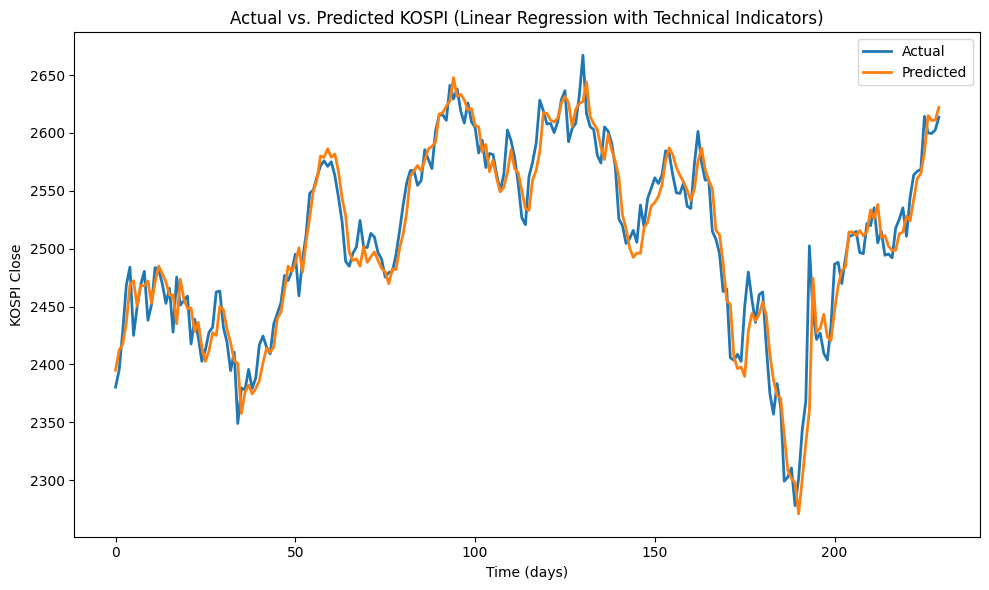

In [8]:
import matplotlib.pyplot as plt

# Make predictions using the best model (LinearRegression with Part 2 data)
best_model = LinearRegression()
best_model.fit(X_train2, y_train2)
y_pred = best_model.predict(X_test2)

# Plot actual vs. predicted
plt.figure(figsize=(10,6))
plt.plot(y_test2.values, label='Actual', linewidth=2)
plt.plot(y_pred, label='Predicted', linewidth=2)
plt.xlabel('Time (days)')
plt.ylabel('KOSPI Close')
plt.title('Actual vs. Predicted KOSPI (Linear Regression with Technical Indicators)')
plt.legend()
plt.tight_layout()
plt.show()


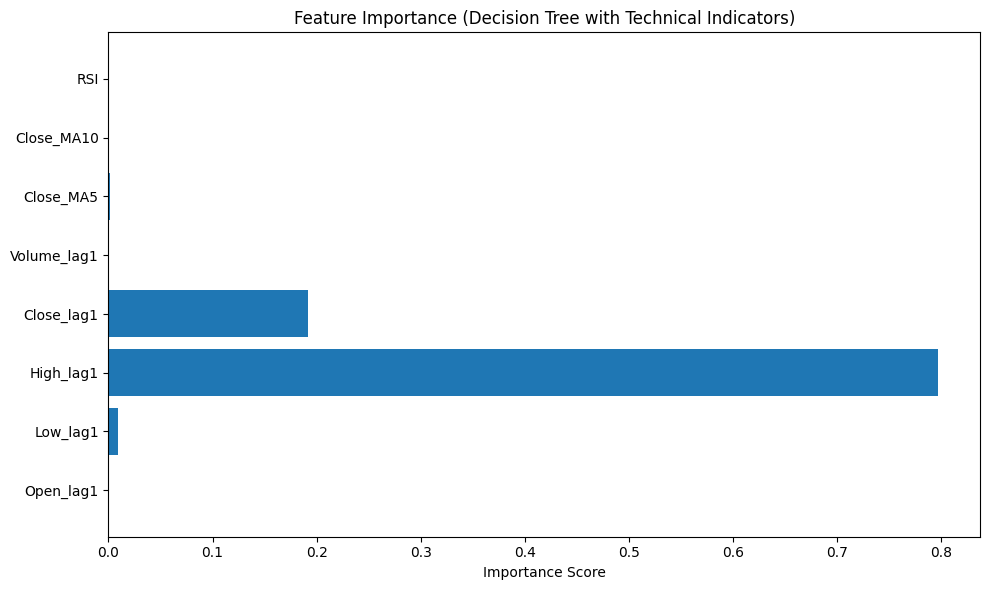

In [9]:
# Train Decision Tree on Part 2
tree_model = DecisionTreeRegressor(max_depth=5, random_state=0)
tree_model.fit(X_train2, y_train2)

# Get feature importances
importances = tree_model.feature_importances_
features_names = X_train2.columns

# Plot feature importances
plt.figure(figsize=(10,6))
plt.barh(features_names, importances)
plt.xlabel('Importance Score')
plt.title('Feature Importance (Decision Tree with Technical Indicators)')
plt.tight_layout()
plt.show()
